In [2]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

plt.rcParams['font.family'] = "Times New Roman"

In [5]:
metrics_json_paths = glob(f'.{os.sep}logs{os.sep}finetune_20250720{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}assessment_metrics.json')
print(f'Found {len(metrics_json_paths)} metrics JSON files.')

Found 504 metrics JSON files.


In [6]:
metrics_records = []
for metrics_json in metrics_json_paths:
    split_path_parts = metrics_json.split(os.sep)
    for i, part in enumerate(split_path_parts):
        print(f'Part {i}: {part}')
    model = split_path_parts[3]
    pretrain_method = split_path_parts[4]
    frozen_encoder = split_path_parts[6] == 'frozenencoder_true'
    n_train = split_path_parts[7]
    fold = split_path_parts[8].split('_')[-1]
    
    metrics = json.load(open(metrics_json, 'r'))
    metrics['model'] = model
    metrics['pretrain_method'] = pretrain_method
    metrics['frozen_encoder'] = frozen_encoder
    metrics['n_train'] = n_train
    metrics['fold'] = fold
    metrics_records.append(metrics)

metrics_df = pd.DataFrame(metrics_records)
metrics_df = metrics_df.loc[(metrics_df['frozen_encoder'] == False) | ((metrics_df['frozen_encoder'] == True) & (metrics_df['model'] == 'linear_probe'))]
# metrics_df.loc[metrics_df['model'] == 'linear_probe']
display(metrics_df.sort_values(by='macro_f1_score', ascending=False))

Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_1
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_2
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_3
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_4
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 500
Part 8: fold_1
P

,accuracy,f1_score,precision,recall,jaccard,kappa,cross_entropy,brier_score,macro_f1_score,macro_precision,...,weighted_precision,weighted_recall,weighted_jaccard,weighted_cross_entropy,weighted_brier_score,model,pretrain_method,frozen_encoder,n_train,fold
397,0.87420,0.87420,0.87420,0.87420,0.776514,0.780977,1.555658,0.027611,0.758441,0.780296,...,0.873818,0.87420,0.784597,1.555658,0.027611,unet,byol,False,500,2
10,0.87000,0.87000,0.87000,0.87000,0.769912,0.772725,1.547689,0.027623,0.755805,0.792217,...,0.869808,0.87000,0.777545,1.547689,0.027623,attention_unet,byol,False,750,1
403,0.86608,0.86608,0.86608,0.86608,0.763793,0.767772,1.531117,0.027326,0.749963,0.778301,...,0.868009,0.86608,0.774044,1.531117,0.027326,unet,byol,False,750,2
399,0.86668,0.86668,0.86668,0.86668,0.764727,0.768611,1.586395,0.030452,0.746120,0.780185,...,0.866062,0.86668,0.774897,1.586395,0.030452,unet,byol,False,500,4
7,0.86540,0.86540,0.86540,0.86540,0.762736,0.766274,1.557559,0.028729,0.744720,0.772592,...,0.864943,0.86540,0.773159,1.557559,0.028729,attention_unet,byol,False,500,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,500,5
164,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,750,1
165,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,750,2
166,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,750,3


In [7]:
metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).count()

accuracy  f1_score  \
model          pretrain_method frozen_encoder n_train                       
attention_unet byol            False          250             4         4   
                                              500             6         6   
                                              750             4         4   
               byol_randinit   False          250             4         4   
                                              500             6         6   
...                                                         ...       ...   
upernet        imagenet        False          500             6         6   
                                              750             4         4   
               none            False          250             4         4   
                                              500             6         6   
                                              750             4         4   

                                                       precision  recall  \
model          pretrain_method frozen_encoder n_train                      
attention_unet byol            False          250              4       4   
                                              500              6       6   
                                              750              4       4   
               byol_randinit   False          250              4       4   
                                              500              6       6   
...                                                          ...     ...   
upernet        imagenet        False          500              6       6   
                                              750              4       4   
               none            False          250              4       4   
                                              500              6       6   
                                              750              4       4   

                                                       jaccard  kappa  \
model          pretrain_method frozen_encoder n_train                   
attention_unet byol            False          250            4      4   
                                              500            6      6   
                                              750            4      4   
               byol_randinit   False          250            4      4   
                                              500            6      6   
...                                                        ...    ...   
upernet        imagenet        False          500            6      6   
                                              750            4      4   
               none            False          250            4      4   
                                              500            6      6   
                                              750            4      4   

                                                       cross_entropy  \
model          pretrain_method frozen_encoder n_train                  
attention_unet byol            False          250                  4   
                                              500                  6   
                                              750                  4   
               byol_randinit   False          250                  4   
                                              500                  6   
...                                                              ...   
upernet        imagenet        False          500                  6   
                                              750                  4   
               none            False          250                  4   
                                              500                  6   
                                              750                  4   

                                                       brier_score  \
model          pretrain_method frozen_encoder n_train                
attention_unet byol            False 

In [ ]:


# fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

# for i, frozen_encoder in enumerate(metrics_df['frozen_encoder'].unique()):
#     # print(i, model)
#     for j, model in enumerate(metrics_df['model'].unique()):
#         # metrics_df['model']
#         # print(j, frozen_encoder)
#         subset = metrics_df[(metrics_df['model'] == model) & (metrics_df['frozen_encoder'] == frozen_encoder)]
#         # sns.lineplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j])
#         # sns.catplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', kind='point', ax=ax[i, j], markers=['o', 's', 'D'], linestyles=['-', '--', ':'])
#         # sns.pointplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j], dodge=True, errorbar='iqr')
#         sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
#         sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], jitter=True, dodge=True, palette='Set2', size=10)
#         handles, labels = ax[i, j].get_legend_handles_labels()
#         # ax[i, j].legend(handles=[(handles[0], handles[2]), (handles[1], handles[3])],
#                 # labels=['BYOL', 'ImageNet'],
#                 # loc='lower right', handlelength=4,
#                 # handler_map={tuple: HandlerTuple(ndivide=None)})
#         ax[i, j].set_title(f'Model: {model}, Frozen Encoder: {frozen_encoder}')
#         ax[i, j].set_xlabel('Number of Training Samples')
#         ax[i, j].set_ylabel('mIOU')

C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\448445254.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


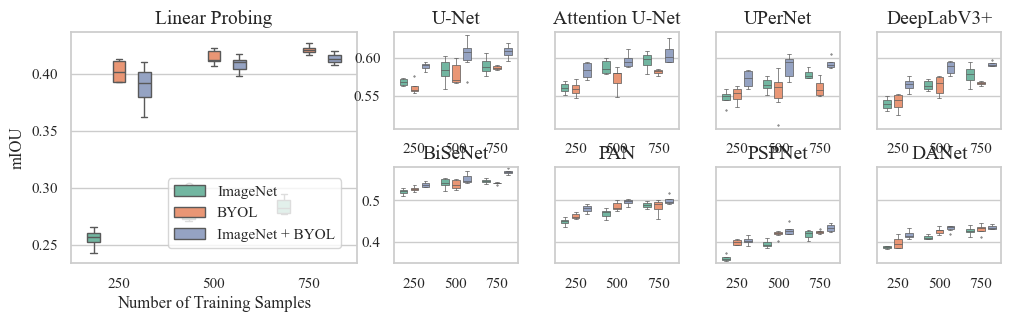

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

size = 3
fig = plt.figure(figsize=(4*size, size))
gs = fig.add_gridspec(2, 6, hspace=0.4, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        # ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        # ax = fig.add_subplot(gs[1, j])
        ax = fig.add_subplot(gs[1, j]) #, sharey=top_axes[0])
    else:  # Share y-axis with first subplot
        # ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

# metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
# new_rows = []
# metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

# for i, row in metrics_df_temp.iterrows():
    # if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        # for fold in range(1, 6):
            # new_row = row.copy()
            # new_row['fold'] = fold
            # new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            # new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
# synthetic_df = pd.DataFrame(new_rows)
# metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

metrics_df_temp = metrics_df.copy()
metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['pretrain_method'] != 'none']

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
    'attention_unet': 'Attention U-Net',
})

metrics_df_temp['Pretrain Method'] = metrics_df_temp['pretrain_method'].replace({
    'byol': 'ImageNet + BYOL',
    'imagenet': 'ImageNet',
    'byol_randinit': 'BYOL'
})
metrics_df_temp['Pretrain Method'] = metrics_df_temp['Pretrain Method'].astype('category').cat.reorder_categories([
    'ImageNet', 'BYOL', 'ImageNet + BYOL'
], ordered=True)

# Plot linear probe
# sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'], 
#             x='n_train', y='macro_jaccard', hue='pretrain_method', 
#             ax=lp_ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
                x='n_train', y='macro_jaccard', hue='Pretrain Method', 
                ax=lp_ax, dodge=True, palette='Set2', gap=0.5)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')

# move legend to lower right corner
handles, labels = lp_ax.get_legend_handles_labels()
lp_ax.legend(handles=handles, labels=labels, loc='lower right', bbox_to_anchor=(1., 0), borderaxespad=1.)


metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['model'] != "linear_probe"]

# order models in a certain order

metrics_df_temp['model'] = metrics_df_temp['model'].astype('category')
metrics_df_temp['model'] = metrics_df_temp['model'].cat.reorder_categories([
    'U-Net', 'Attention U-Net', 'DeepLabV3+', 'UPerNet',
    'BiSeNet', 'DANet', 'PAN', 'PSPNet',
], ordered=True)

# Plot other models

model_list = metrics_df_temp.sort_values(by='macro_jaccard', ascending=False)['model'].unique()

for i, (ax, model) in enumerate(zip(axes, model_list)):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    
    # sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method', 
    #             ax=ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False, legend=False)
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
                  ax=ax, dodge=True, palette='Set2', 
                    legend=False, gap=0.3, fliersize=0.5, linewidth=0.5)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
    #     ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')

top_axes = axes[:4]
bottom_axes = axes[4:]


y_max_top = max(ax.get_ylim()[1] for ax in top_axes if ax.get_ylim()[1] is not None)
y_min_top = min(ax.get_ylim()[0] for ax in top_axes if ax.get_ylim()[0] is not None)
for i, ax in enumerate(top_axes):
    ax.set_ylim(y_min_top, y_max_top)
    if i not in [0, 4]:
        ax.set_yticklabels([])
        # make ax a little wider
    
    figw = fig.get_size_inches()[0]
    # ax.set_size(3*size, size)

y_max_bottom = max(ax.get_ylim()[1] for ax in bottom_axes if ax.get_ylim()[1] is not None)
y_min_bottom = min(ax.get_ylim()[0] for ax in bottom_axes if ax.get_ylim()[0] is not None)
for i, ax in enumerate(bottom_axes):
    ax.set_ylim(y_min_bottom, y_max_bottom)
    if i not in [0, 4]:
        ax.set_yticklabels([])
        
# increase text size of titles and labels
for ax in axes:
    ax.title.set_fontsize(14)
lp_ax.title.set_fontsize(14)

fig.tight_layout()

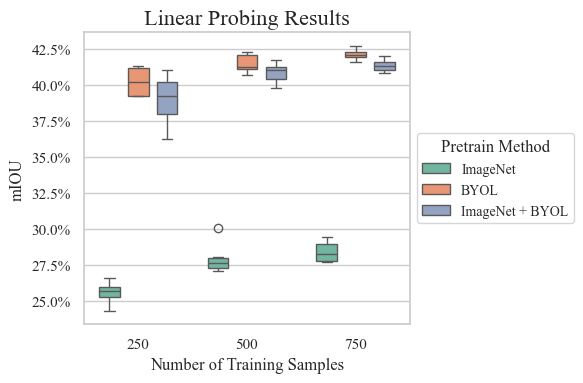

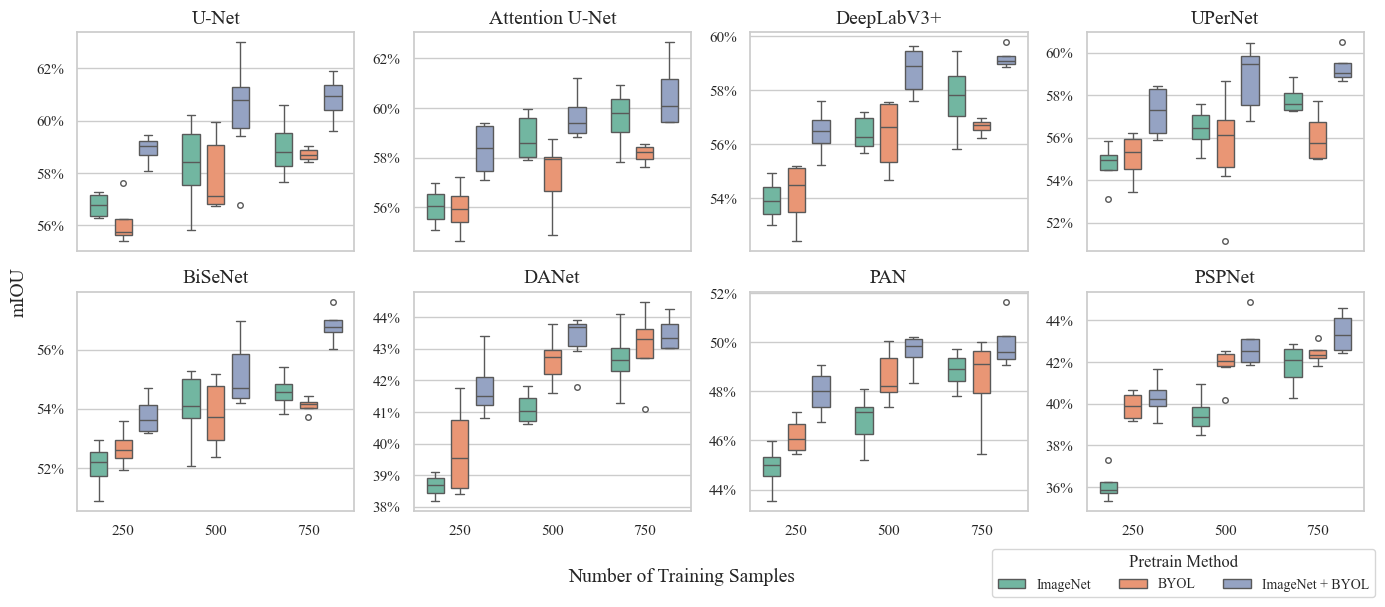

In [110]:
# --- Plot 1: Linear Probing Results ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import PercentFormatter

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

# --- Data Preparation ---
metrics_df_temp = metrics_df.copy()
metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['pretrain_method'] != 'none']

# Rename for clarity in the plot
metrics_df_temp['Pretrain Method'] = metrics_df_temp['pretrain_method'].replace({
    'byol': 'ImageNet + BYOL',
    'imagenet': 'ImageNet',
    'byol_randinit': 'BYOL'
})
metrics_df_temp['Pretrain Method'] = metrics_df_temp['Pretrain Method'].astype('category').cat.reorder_categories([
    'ImageNet', 'BYOL', 'ImageNet + BYOL'
], ordered=True)

# Filter for linear probing data
linear_probe_df = metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'].copy()

# --- Plotting ---
size=4
fig, ax = plt.subplots(figsize=(1.5*size, size))

sns.boxplot(data=linear_probe_df,
            x='n_train', y='macro_jaccard', hue='Pretrain Method', 
            ax=ax, dodge=True, palette='Set2', gap=0.3)

ax.set_title('Linear Probing Results', fontsize=16)
ax.set_xlabel('Number of Training Samples', fontsize=12)
ax.set_ylabel('mIOU', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.legend(loc='center left', title='Pretrain Method', bbox_to_anchor=(1, 0.5), fontsize=10)

plt.tight_layout()
plt.savefig('./paper/images/linear_probing_results.pdf')
plt.savefig('./paper/images/linear_probing_results.png', dpi=300)
plt.show()


sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

# --- Data Preparation ---
metrics_df_temp = metrics_df.copy()
metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['pretrain_method'] != 'none']

# Filter out linear probe and non-finetuning runs
finetune_df = metrics_df_temp[(metrics_df_temp['model'] != 'linear_probe') & (metrics_df_temp['frozen_encoder'] == False)].copy()

# Rename models for display
finetune_df['model'] = finetune_df['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
    'attention_unet': 'Attention U-Net',
})

# Rename pretrain methods for display
finetune_df['Pretrain Method'] = finetune_df['pretrain_method'].replace({
    'byol': 'ImageNet + BYOL',
    'imagenet': 'ImageNet',
    'byol_randinit': 'BYOL'
})

# Set order for models and pretrain methods
finetune_df['Pretrain Method'] = finetune_df['Pretrain Method'].astype('category').cat.reorder_categories([
    'ImageNet', 'BYOL', 'ImageNet + BYOL'
], ordered=True)

model_order = [
    'U-Net', 'Attention U-Net', 'DeepLabV3+', 'UPerNet',
    'BiSeNet', 'DANet', 'PAN', 'PSPNet',
]
finetune_df['model'] = finetune_df['model'].astype('category').cat.reorder_categories(model_order, ordered=True)
finetune_df = finetune_df.sort_values('model')
finetune_df['n_train'] = finetune_df['n_train'].astype(int)

# --- Plotting ---
fig, axes = plt.subplots(2, 4, figsize=(3.5*size, 1.5*size), sharey=False, sharex=True)
axes = axes.flatten() # Flatten for easy iteration

for i, model in enumerate(model_order):
    ax = axes[i]
    subset = finetune_df[finetune_df['model'] == model]
    
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
                ax=ax, dodge=True, palette='Set2', 
                legend=True if i == 0 else False, gap=0.3, fliersize=4, linewidth=1)
    
    ax.set_title(model, fontsize=14)
    ax.set_ylabel('') # Clear individual y-labels
    ax.set_xlabel('') # Clear individual x-labels
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Set shared labels
fig.supylabel('mIOU', fontsize=14)
fig.supxlabel('Number of Training Samples', fontsize=14)

# Create and place a single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(1, -0.02), ncol=3, title='Pretrain Method', fontsize=10)
axes[0].legend_.remove()  # Remove the legend from the first subplot

# plt.tight_layout(rect=[0.03, 0.03, 1, 1]) # Adjust layout to make room for legend
plt.tight_layout()

plt.savefig('./paper/images/finetuning_results.pdf')
plt.savefig('./paper/images/finetuning_results.png', dpi=300)
plt.show()

In [103]:
# generate a table with mean accuracy, macro jaccard for each model, pretrainn method, and n_train combination

mean_metics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(
    mean_accuracy=('accuracy', 'mean'),
    mean_macro_jaccard=('macro_jaccard', 'mean'),
).reset_index()
mean_metics_df = mean_metics_df.loc[(mean_metics_df['Pretrain Method'] != 'None') & (mean_metics_df['model'] == 'U-Net')]

# convert to percentage
mean_metics_df['mean_accuracy'] = mean_metics_df['mean_accuracy'] * 100
mean_metics_df['mean_macro_jaccard'] = mean_metics_df['mean_macro_jaccard'] * 100

display(mean_metics_df)

max_metrics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(
    max_accuracy=('accuracy', 'max'),
    max_macro_jaccard=('macro_jaccard', 'max'),
).reset_index()
max_metrics_df = max_metrics_df.loc[(max_metrics_df['Pretrain Method'] != 'None') & (max_metrics_df['model'] == 'U-Net')]

# convert to percentage
max_metrics_df['max_accuracy'] = max_metrics_df['max_accuracy'] * 100
max_metrics_df['max_macro_jaccard'] = max_metrics_df['max_macro_jaccard'] * 100

display(max_metrics_df)

C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\2564544940.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_metics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(


,model,Pretrain Method,n_train,mean_accuracy,mean_macro_jaccard
0,U-Net,ImageNet,250,85.204000,56.768009
1,U-Net,ImageNet,500,85.696667,58.332960
2,U-Net,ImageNet,750,86.104000,58.973782
3,U-Net,BYOL,250,85.341000,56.125655
4,U-Net,BYOL,500,86.195333,57.898945
5,U-Net,BYOL,750,86.246000,58.707838
6,U-Net,ImageNet + BYOL,250,85.946000,58.897566
7,U-Net,ImageNet + BYOL,500,86.550000,60.359523
8,U-Net,ImageNet + BYOL,750,86.428000,60.851484


C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\2564544940.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_metrics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(


,model,Pretrain Method,n_train,max_accuracy,max_macro_jaccard
0,U-Net,ImageNet,250,85.400,57.281695
1,U-Net,ImageNet,500,86.200,60.237492
2,U-Net,ImageNet,750,86.660,60.612650
3,U-Net,BYOL,250,85.616,57.629868
4,U-Net,BYOL,500,86.836,59.957926
5,U-Net,BYOL,750,86.576,59.016645
6,U-Net,ImageNet + BYOL,250,86.440,59.456537
7,U-Net,ImageNet + BYOL,500,87.420,63.005163
8,U-Net,ImageNet + BYOL,750,86.608,61.909370


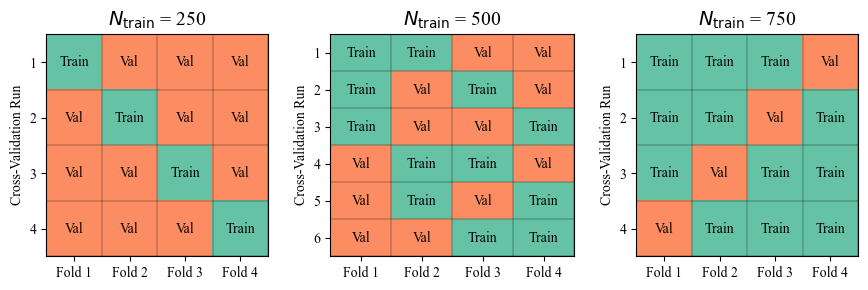

In [10]:
# fold plots
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# custom colormap:
set2_colors = sns.color_palette('Set2', n_colors=2)
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(set2_colors)

splits_df = pd.read_csv('./data/splits/splits.csv')
# display(splits_df)

size = 3
fig, axes = plt.subplots(1, len(splits_df['n_train'].unique()), 
                        figsize=(3*size, size), sharex=True)

colors = {'train': 'lightblue', 'val': 'lightcoral'}

for i, n_train in enumerate(splits_df['n_train'].unique()):
    subset = splits_df[splits_df['n_train'] == n_train]
    
    # Create grid for this n_train
    grid_data = np.zeros((len(subset), 4))
    for j, (_, row) in enumerate(subset.iterrows()):
        for k, split in enumerate(['split_1', 'split_2', 'split_3', 'split_4']):
            grid_data[j, k] = row[split] == 'val'
    
    im = axes[i].imshow(grid_data, cmap=cmap, aspect='auto' if i == 1 else 'equal')
    
    # Add text annotations
    for j in range(len(subset)):
        for k in range(4):
            role = subset.iloc[j][f'split_{k+1}'].replace('train', 'Train').replace('val', 'Val')
            axes[i].text(k, j, role, ha='center', va='center', 
                        color='black' if grid_data[j, k] == 1 else 'black')
    
    for x in range(4 + 1):  # vertical lines
        axes[i].axvline(x - 0.5, color='black', linewidth=0.25)
    for y in range(len(subset) + 1):  # horizontal lines
        axes[i].axhline(y - 0.5, color='black', linewidth=0.25)
    
    
    axes[i].set_title(r'$N_{\text{train}}$ = ' + str(n_train))
    axes[i].set_ylabel('Cross-Validation Run')
    axes[i].set_yticks(range(len(subset)))
    axes[i].set_yticklabels(subset['fold'].values)
    
    # if i == len(splits_df['n_train'].unique()) - 1:
    # axes[i].set_xlabel('Split')
    axes[i].set_xticks(range(4))
    # axes[i].set_xticklabels(['Split 1', 'Split 2', 'Split 3', 'Split 4'])
    axes[i].set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4'])

for ax in axes:
    ax.grid(False)
    ax.title.set_fontsize(14)
    
plt.tight_layout()
plt.savefig('./paper/images/fold_splits.pdf', bbox_inches='tight')
plt.savefig('./paper/images/fold_splits.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_39740\2434215442.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


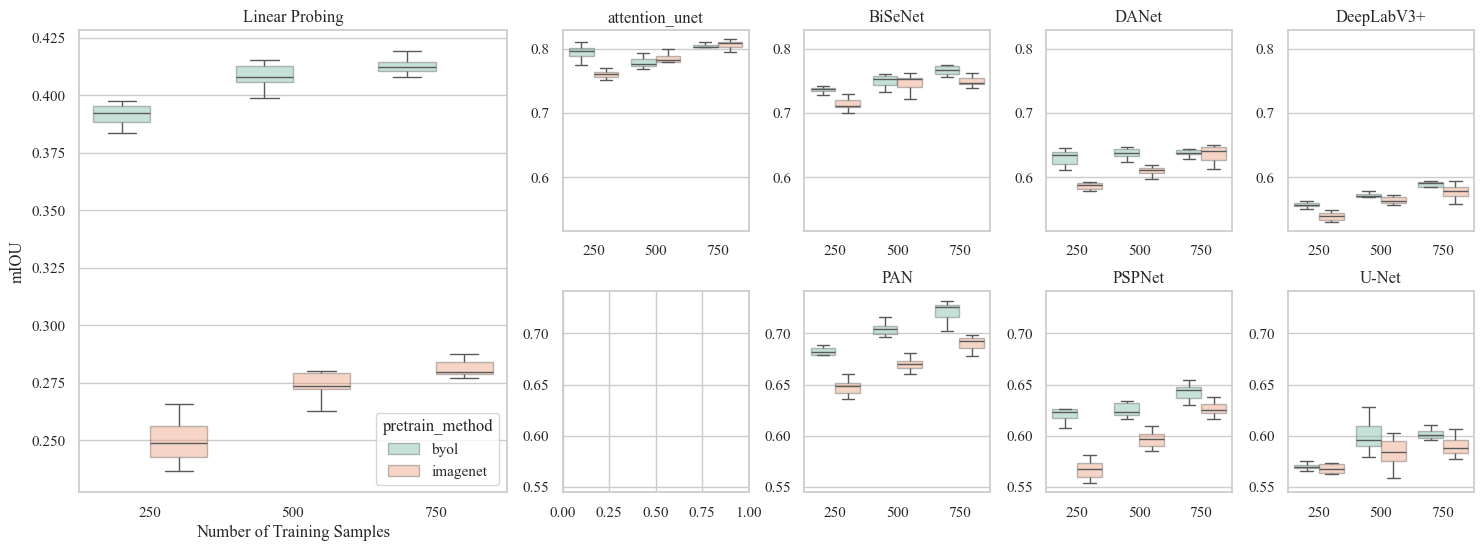

In [63]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        ax = fig.add_subplot(gs[1, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
new_rows = []
metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

for i, row in metrics_df_temp.iterrows():
    if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        for fold in range(1, 6):
            new_row = row.copy()
            new_row['fold'] = fold
            new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
synthetic_df = pd.DataFrame(new_rows)
metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
})
    

# Plot linear probe
sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'], 
            x='n_train', y='macro_jaccard', hue='pretrain_method', 
            ax=lp_ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
# sns.stripplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
#                 x='n_train', y='macro_jaccard', hue='pretrain_method', 
#                 ax=lp_ax, jitter=True, dodge=True, palette='Set2', size=10)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')


# Plot other models
for ax, model in zip(axes, metrics_df_temp['model'].unique()):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', 
                ax=ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False, legend=False)
    # sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
    #               ax=ax, jitter=True, dodge=True, palette='Set2', size=10,
    #                 legend=False, alpha=0.7)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


fig.tight_layout()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_24924\2825723249.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


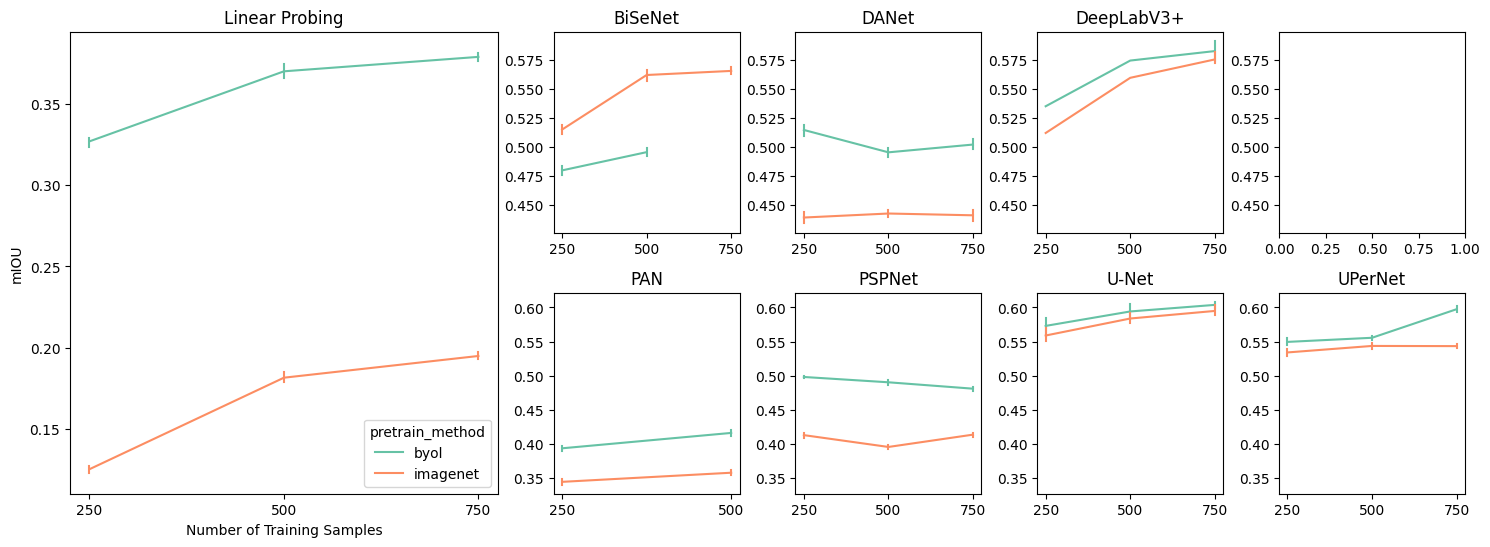

In [114]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        ax = fig.add_subplot(gs[1, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
new_rows = []
metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

for i, row in metrics_df_temp.iterrows():
    if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        for fold in range(1, 6):
            new_row = row.copy()
            new_row['fold'] = fold
            new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
synthetic_df = pd.DataFrame(new_rows)
metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
})
    

# Plot linear probe
sns.lineplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
            x='n_train', y='macro_jaccard', hue='pretrain_method', 
            ax=lp_ax, palette='Set2', err_style='bars')
# sns.stripplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
#                 x='n_train', y='macro_jaccard', hue='pretrain_method', 
#                 ax=lp_ax, jitter=True, dodge=True, palette='Set2', size=10)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')


# Plot other models
for ax, model in zip(axes, metrics_df_temp['model'].unique()):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    

    sns.lineplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
                ax=ax, palette='Set2', legend=False, err_style='bars')
    # sns.catplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', 
    #             ax=ax, palette='Set2', legend=False)
    # sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
    #               ax=ax, jitter=True, dodge=True, palette='Set2', size=10,
    #                 legend=False, alpha=0.7)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


fig.tight_layout()